In [1]:
%pip install -U pip
%pip install tensorflow pydot

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Tensorflow:", tf.__version__)


Tensorflow: 2.21.0


In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print ("Train images:", x_train.shape, "Train labels:", y_train.shape)
print ("Test images:", x_test.shape, "Test labels:", y_test.shape) #must be 10000 test images

Train images: (60000, 28, 28) Train labels: (60000,)
Test images: (10000, 28, 28) Test labels: (10000,)


In [4]:
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test = (x_test.astype("float32") / 255.0)[..., None]

print("After preprocess train:", x_train.shape)
print("After preprocess test:", x_test.shape)

After preprocess train: (60000, 28, 28, 1)
After preprocess test: (10000, 28, 28, 1)


In [5]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=2
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 - 6s - 14ms/step - accuracy: 0.9318 - loss: 0.2283 - val_accuracy: 0.9795 - val_loss: 0.0727
Epoch 2/5
422/422 - 5s - 13ms/step - accuracy: 0.9802 - loss: 0.0633 - val_accuracy: 0.9888 - val_loss: 0.0426
Epoch 3/5
422/422 - 5s - 13ms/step - accuracy: 0.9864 - loss: 0.0435 - val_accuracy: 0.9897 - val_loss: 0.0373
Epoch 4/5
422/422 - 6s - 13ms/step - accuracy: 0.9895 - loss: 0.0333 - val_accuracy: 0.9902 - val_loss: 0.0346
Epoch 5/5
422/422 - 6s - 13ms/step - accuracy: 0.9918 - loss: 0.0254 - val_accuracy: 0.9910 - val_loss: 0.0346


In [6]:
model.save("model.keras")
print("Saved model.keras")

Saved model.keras


In [7]:
import os
print(os.listdir("."))

['Untitled Folder', 'JS_CG.html', 'My-Excel-task-06.xlsx', '.zshrc.save', '.cortex-debug', 'Music', 'send_assignment.sh ', 'C_Project_Embedded_System_course', 'map.html', 'project_gradcam:', 'Functional-Abstraction-Ebike.pptx', '~$andari_Prashant_Word01.docx', 'My_excel_task_04.xlsx', 'Scenario1_P.pages', 'Untitled1.ipynb', '.micropico-stubs', 'index.html', 'server_project', '.DS_Store', ' bb4749b9-e5cc-4f24-a686-31c5be7bfdc1.mov', 'LearningDiary_DigitalToolAndData.pdf', 'css_cg.html', 'ML_1_2.ipynb', 'send_assignment.sh', 'Website_Profit-loss', 'school.sqbpro', 'keras-assignment', 'Prashant – Heatmap Integration Research Summary.pdf', 'physicsproject.pptx', 'VirtualBox VMs', '.CFUserTextEncoding', 'MovementApp', 'Untitled.ipynb', 'Lesson_1 (1).pdf', 'Finnish_code_validate_2.html', '.zshrc', 'model_diagram.png', 'ML_exam', '.local', 'task_8_LoopTask.html', 'Pictures', 'my_backend', 'My_Excel_03.xlsx', '.zprofile', 'Team___6', 'My_excel_task_05-text function.xlsx', 'Finnish2Homework.pag

In [8]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file="model_diagram.png", show_shapes=True, show_layer_names=True)
print("Saved model_diagram.png")

Saved model_diagram.png


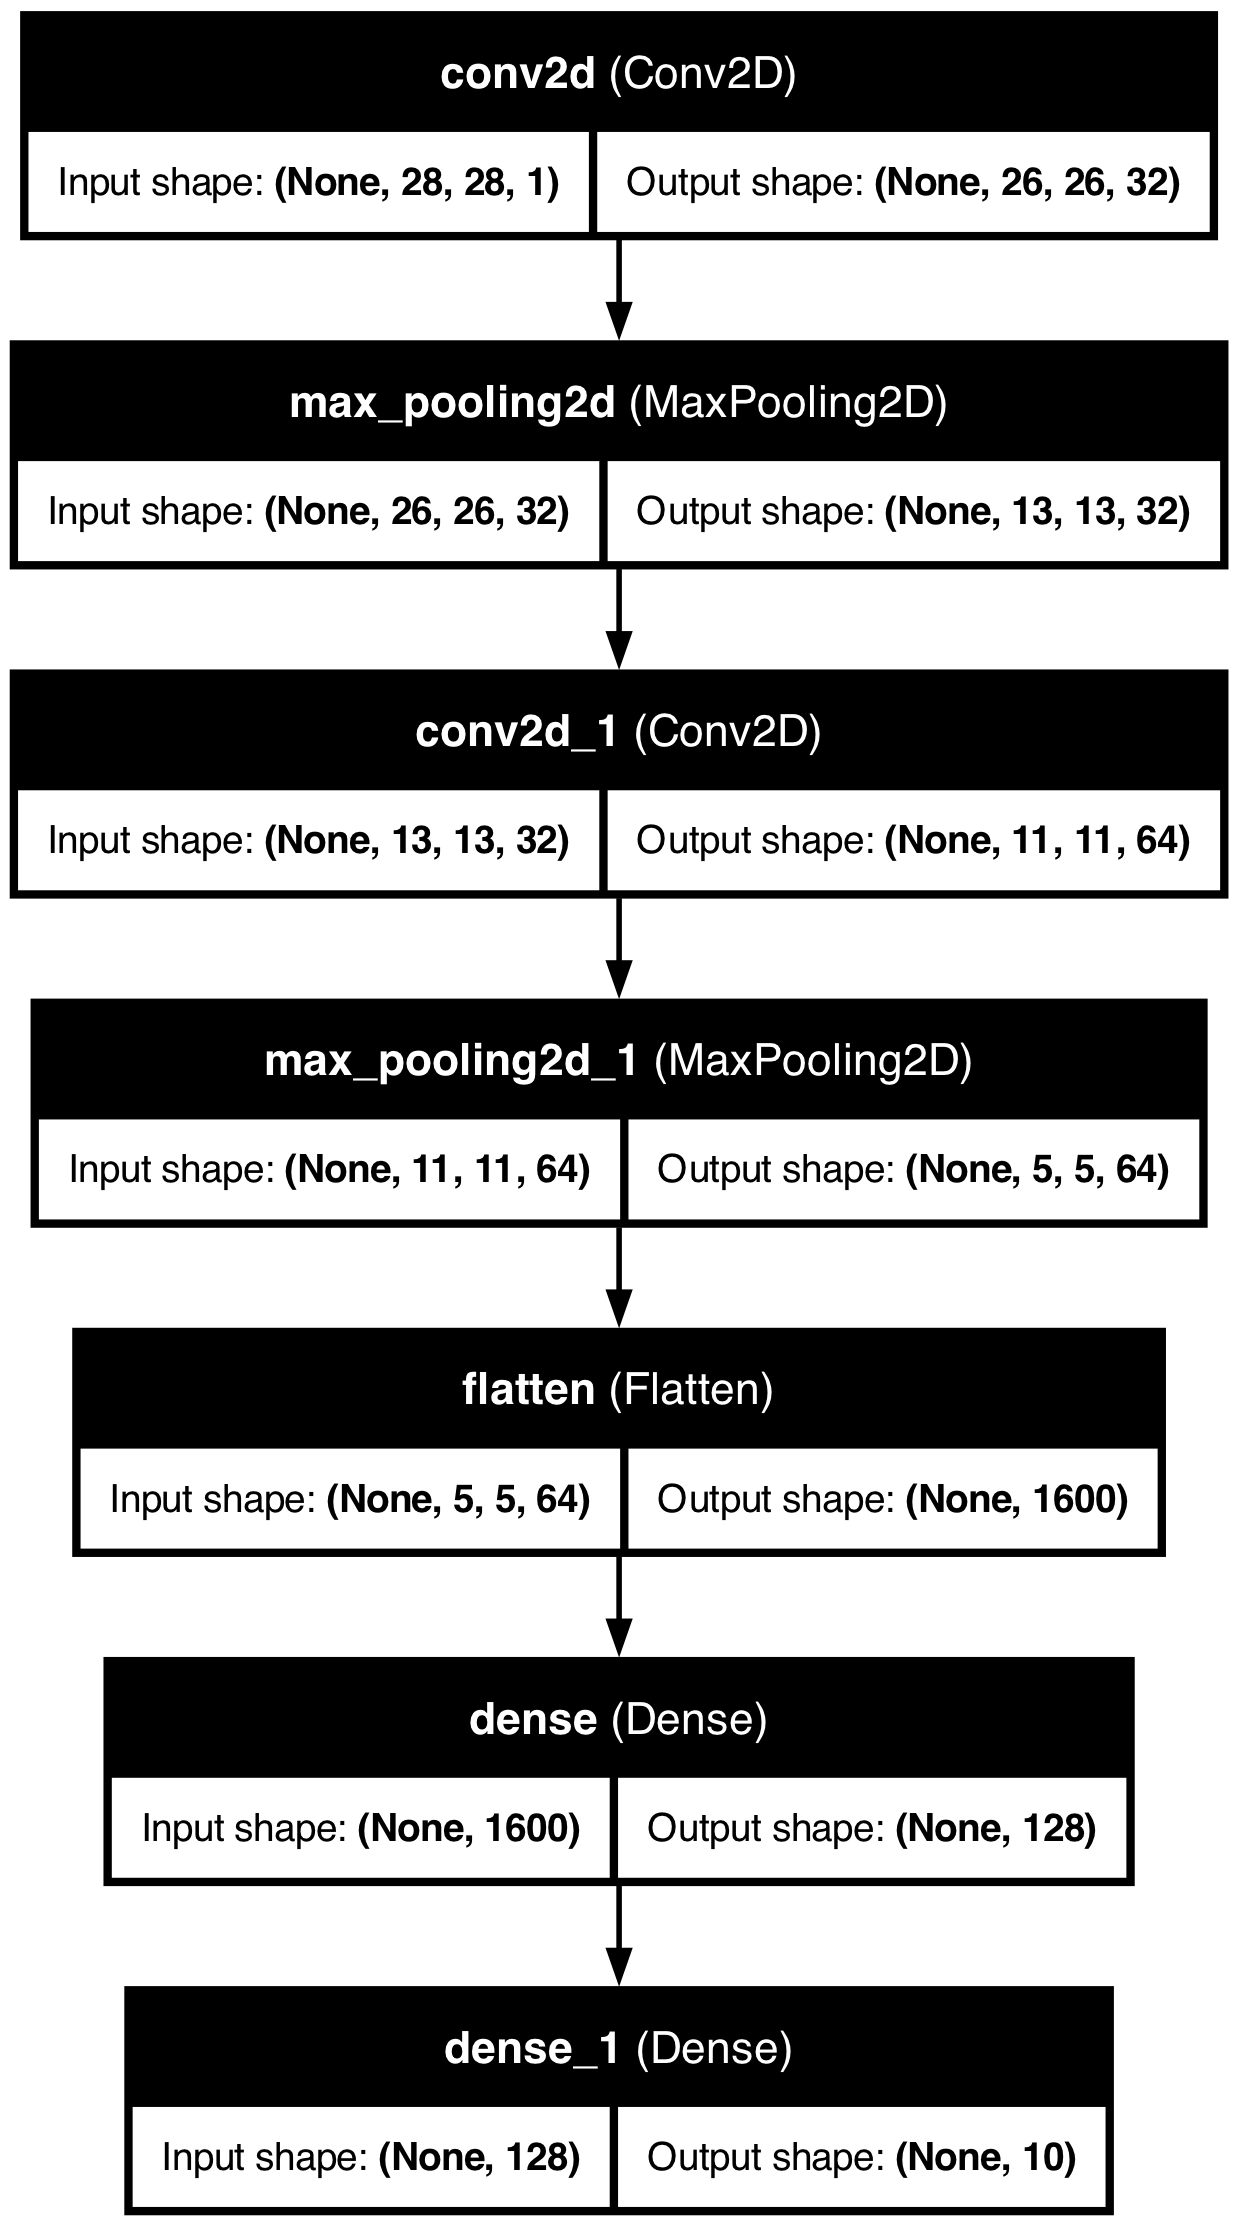

In [9]:
from IPython.display import Image, display
display(Image("model_diagram.png"))

In [10]:
def reward_from_correct(n_correct: int) -> int:
    n1 = min(n_correct, 5000)
    n2 = min(max(n_correct - 5000, 0), 1000)
    n3 = max(n_correct - 6000, 0)
    return n1*100 + n2*200 + n3*1000

probs = model.predict(x_test, batch_size=256, verbose=0)
y_pred = np.argmax(probs, axis=1)

n_correct = int(np.sum(y_pred == y_test))
total_params = model.count_params()

reward = reward_from_correct(n_correct)
net_score = reward - total_params

print(f"Correct predictions: {n_correct} / 10000")
print(f"Reward: {reward}")
print(f"TotalParams: {total_params}")
print(f"Net Score = Reward - TotalParams: {net_score}")

Correct predictions: 9901 / 10000
Reward: 4601000
TotalParams: 225034
Net Score = Reward - TotalParams: 4375966


In [11]:
import os
files = os.listdir(".")
print(files)

['Untitled Folder', 'JS_CG.html', 'My-Excel-task-06.xlsx', '.zshrc.save', '.cortex-debug', 'Music', 'send_assignment.sh ', 'C_Project_Embedded_System_course', 'map.html', 'project_gradcam:', 'Functional-Abstraction-Ebike.pptx', '~$andari_Prashant_Word01.docx', 'My_excel_task_04.xlsx', 'Scenario1_P.pages', 'Untitled1.ipynb', '.micropico-stubs', 'index.html', 'server_project', '.DS_Store', ' bb4749b9-e5cc-4f24-a686-31c5be7bfdc1.mov', 'LearningDiary_DigitalToolAndData.pdf', 'css_cg.html', 'ML_1_2.ipynb', 'send_assignment.sh', 'Website_Profit-loss', 'school.sqbpro', 'keras-assignment', 'Prashant – Heatmap Integration Research Summary.pdf', 'physicsproject.pptx', 'VirtualBox VMs', '.CFUserTextEncoding', 'MovementApp', 'Untitled.ipynb', 'Lesson_1 (1).pdf', 'Finnish_code_validate_2.html', '.zshrc', 'model_diagram.png', 'ML_exam', '.local', 'task_8_LoopTask.html', 'Pictures', 'my_backend', 'My_Excel_03.xlsx', '.zprofile', 'Team___6', 'My_excel_task_05-text function.xlsx', 'Finnish2Homework.pag